In [ ]:
from IPython.display import Image

# 直接使用 Hugging Face 的图片 URL
Image(url='https://huggingface.co/blog/assets/78_annotated-diffusion/ddpm_paper.png', width=600)

Install Package


In [ ]:
!pip install -q -U einops datasets matplotlib tqdm

import math
from inspect import isfunction
from functools import partial

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, reduce
from einops.layers.torch import Rearrange

import torch
from torch import nn, einsum
import torch.nn.functional as F


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 42.9 MB/s eta 0:00:00


The neural network(U-Net) for Algorithm 1

In [ ]:
#检查变量是否存在
def exists(x):
    return x is not None

#设置默认值
def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

#批次将数据分组
def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

#残差连接
class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

#上采样
def Upsample(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv2d(dim, default(dim_out, dim), 3, padding=1),
    )

#下采样
def Downsample(dim, dim_out=None):
    # No More Strided Convolutions or Pooling
    return nn.Sequential(
        Rearrange("b c (h p1) (w p2) -> b (c p1 p2) h w", p1=2, p2=2),
        nn.Conv2d(dim * 4, default(dim_out, dim), 1),
    )


In [ ]:
# time is t from Algprithm 1

# 通过编码让程序理解时间步数
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [ ]:
class WeightStandardizedConv2d(nn.Conv2d):
    """
    https://arxiv.org/abs/1903.10520
    weight standardization purportedly works synergistically with group normalization
    """

    def forward(self, x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3

        weight = self.weight
        mean = reduce(weight, "o ... -> o 1 1 1", "mean")
        var = reduce(weight, "o ... -> o 1 1 1", partial(torch.var, unbiased=False))
        normalized_weight = (weight - mean) * (var + eps).rsqrt()

        return F.conv2d(
            x,
            normalized_weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )


#ends here


class Block(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = WeightStandardizedConv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x





class ResnetBlock(nn.Module):
    """https://arxiv.org/abs/1512.03385"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out * 2))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        scale_shift = None
        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            time_emb = rearrange(time_emb, "b c -> b c 1 1")
            scale_shift = time_emb.chunk(2, dim=1)

        h = self.block1(x, scale_shift=scale_shift)
        h = self.block2(h)
        return h + self.res_conv(x)


In [ ]:
class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )
        q = q * self.scale

        sim = einsum("b h d i, b h d j -> b h i j", q, k)
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)

        out = einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1),
                                    nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


In [ ]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


In [ ]:
class Unet(nn.Module):
    def __init__(
        self,
        dim,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4, 8),
        channels=3,
        self_condition=False,
        resnet_block_groups=4,
    ):
        super().__init__()

        # determine dimensions
        self.channels = channels
        self.self_condition = self_condition
        input_channels = channels * (2 if self_condition else 1)

        init_dim = default(init_dim, dim)
        self.init_conv = nn.Conv2d(input_channels, init_dim, 1, padding=0) # changed to 1 and 0 from 7,3

        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        block_klass = partial(ResnetBlock, groups=resnet_block_groups)

        # time embeddings
        time_dim = dim * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        # layers
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append(
                nn.ModuleList(
                    [
                        block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                        block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                        Downsample(dim_in, dim_out)
                        if not is_last
                        else nn.Conv2d(dim_in, dim_out, 3, padding=1),
                    ]
                )
            )

        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out)):
            is_last = ind == (len(in_out) - 1)

            self.ups.append(
                nn.ModuleList(
                    [
                        block_klass(dim_out + dim_in, dim_out, time_emb_dim=time_dim),
                        block_klass(dim_out + dim_in, dim_out, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                        Upsample(dim_out, dim_in)
                        if not is_last
                        else nn.Conv2d(dim_out, dim_in, 3, padding=1),
                    ]
                )
            )

        self.out_dim = default(out_dim, channels)

        self.final_res_block = block_klass(dim * 2, dim, time_emb_dim=time_dim)
        self.final_conv = nn.Conv2d(dim, self.out_dim, 1)

    def forward(self, x, time, x_self_cond=None):
        if self.self_condition:
            x_self_cond = default(x_self_cond, lambda: torch.zeros_like(x))
            x = torch.cat((x_self_cond, x), dim=1)

        x = self.init_conv(x)
        r = x.clone()

        t = self.time_mlp(time)

        h = []

        for block1, block2, attn, downsample in self.downs:
            x = block1(x, t)
            h.append(x)

            x = block2(x, t)
            x = attn(x)
            h.append(x)

            x = downsample(x)

        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = block1(x, t)

            x = torch.cat((x, h.pop()), dim=1)
            x = block2(x, t)
            x = attn(x)

            x = upsample(x)

        x = torch.cat((x, r), dim=1)

        x = self.final_res_block(x, t)
        return self.final_conv(x)


forward diffusion

In [ ]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start


In [ ]:
timesteps = 300

# define beta schedule
betas = linear_beta_schedule(timesteps=timesteps)

# define alphas
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)


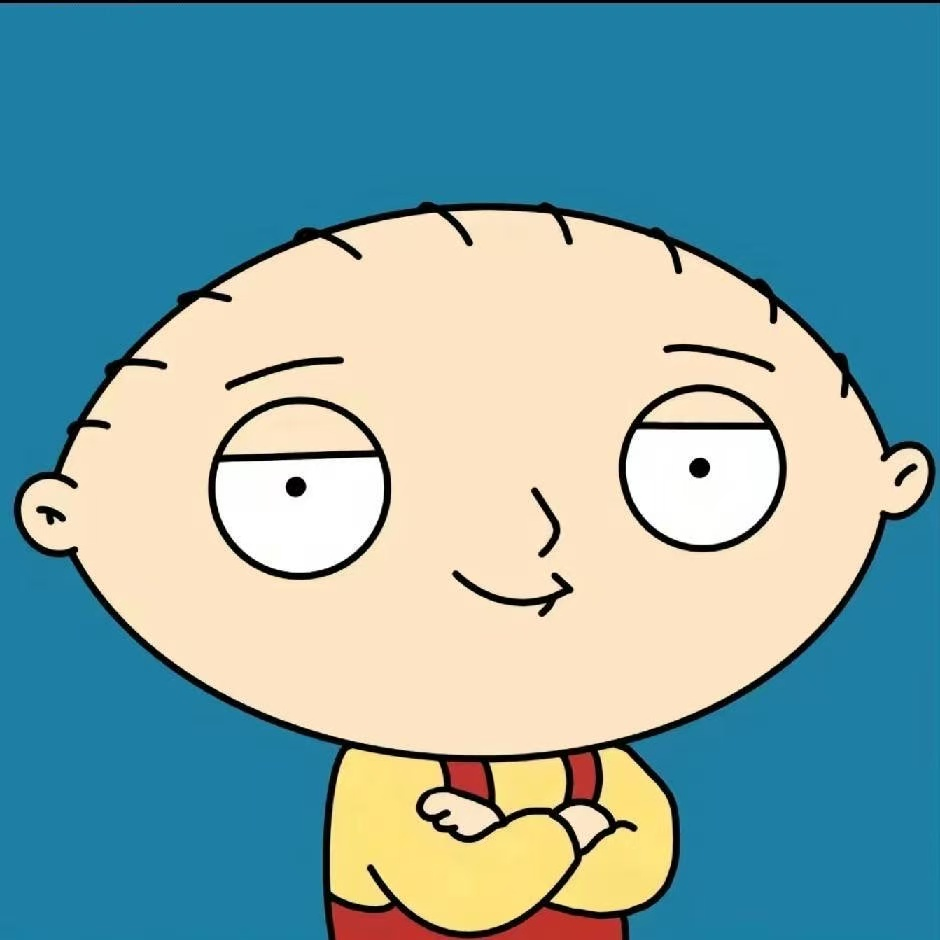

In [ ]:
from PIL import Image
import requests

#url = 'http://images.cocodataset.org/val2017/000000039769.jpg'

#url = 'C:/Users/Legion/Desktop/80a951ac084f586c1d6b4dc2a0f700e6.jpg'
#image = Image.open(requests.get(url, stream=True).raw) # PIL image of shape HWC
#image

from PIL import Image

# 假设上传的图片名为 'my_image.jpg'
image = Image.open('111.jpg')
image



In [ ]:
from torchvision.transforms import Compose, ToTensor, Lambda, ToPILImage, CenterCrop, Resize

image_size = 128
transform = Compose([
    Resize(image_size),
    CenterCrop(image_size),
    ToTensor(), # turn into torch Tensor of shape CHW, divide by 255
    Lambda(lambda t: (t * 2) - 1),

])

x_start = transform(image).unsqueeze(0)
x_start.shape


torch.Size([1, 3, 128, 128])

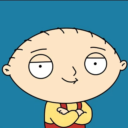

In [ ]:
import numpy as np

reverse_transform = Compose([
     Lambda(lambda t: (t + 1) / 2),
     Lambda(lambda t: t.permute(1, 2, 0)), # CHW to HWC
     Lambda(lambda t: t * 255.),
     Lambda(lambda t: t.numpy().astype(np.uint8)),
     ToPILImage(),
])
reverse_transform(x_start.squeeze())


diffusion process

In [ ]:
# forward diffusion (using the nice property)
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


In [ ]:
def get_noisy_image(x_start, t):
  # add noise
  x_noisy = q_sample(x_start, t=t)

  # turn back into PIL image
  noisy_image = reverse_transform(x_noisy.squeeze())

  return noisy_image


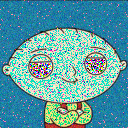

In [ ]:
# take time step
t = torch.tensor([20])

get_noisy_image(x_start, t)


In [ ]:
import matplotlib.pyplot as plt

# use seed for reproducability
torch.manual_seed(0)

# source: https://pytorch.org/vision/stable/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py
def plot(imgs, with_orig=False, row_title=None, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0]) + with_orig
    fig, axs = plt.subplots(figsize=(200,200), nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        row = [image] + row if with_orig else row
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    if with_orig:
        axs[0, 0].set(title='Original image')
        axs[0, 0].title.set_size(8)
    if row_title is not None:
        for row_idx in range(num_rows):
            axs[row_idx, 0].set(ylabel=row_title[row_idx])

    plt.tight_layout()

plot([get_noisy_image(x_start, torch.tensor([t])) for t in [0, 50, 100, 150, 199]])



In [ ]:
def p_losses(denoise_model, x_start, t, noise=None, loss_type="l1"):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)
    predicted_noise = denoise_model(x_noisy, t)

    if loss_type == 'l1':
        loss = F.l1_loss(noise, predicted_noise)
    elif loss_type == 'l2':
        loss = F.mse_loss(noise, predicted_noise)
    elif loss_type == "huber":
        loss = F.smooth_l1_loss(noise, predicted_noise)
    else:
        raise NotImplementedError()

    return loss


dataset rather that single graph

In [ ]:
from datasets import load_dataset

# load dataset from the hub
dataset = load_dataset("fashion_mnist")
image_size = 28
channels = 1
batch_size = 128


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

# define image transformations (e.g. using torchvision)
transform = Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Lambda(lambda t: (t * 2) - 1)
])

# define function
def transforms(examples):
   examples["pixel_values"] = [transform(image.convert("L")) for image in examples["image"]]
   del examples["image"]

   return examples

transformed_dataset = dataset.with_transform(transforms).remove_columns("label")

# create dataloader
dataloader = DataLoader(transformed_dataset["train"], batch_size=batch_size, shuffle=True)


In [ ]:
batch = next(iter(dataloader))
print(batch.keys())


dict_keys(['pixel_values'])


# **Sampling**

**DDPM** **Sampling**

In [ ]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # Equation 11 in the paper
    # Use our model (noise predictor) to predict the mean
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Algorithm 2 line 4:
        return model_mean + torch.sqrt(posterior_variance_t) * noise

# Algorithm 2 (including returning all images)
@torch.no_grad()
def p_sample_loop(model, shape):
    device = next(model.parameters()).device

    b = shape[0]
    # start from pure noise (for each example in the batch)
    img = torch.randn(shape, device=device)
    imgs = []

    for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
        imgs.append(img.cpu().numpy())
    return imgs

@torch.no_grad()
def sample(model, image_size, batch_size=16, channels=3):
    return p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))


**DDIM** **SAMPLING**

In [ ]:
@torch.no_grad()
def ddim_sample(model, shape, num_inference_steps=50, eta=0.0):

    device = next(model.parameters()).device
    b = shape[0]

    # 创建均匀间隔的时间步序列（从 timesteps-1 到 0）
    # 假设训练时 timesteps=1000
    step_size = timesteps // num_inference_steps
    ddim_timesteps = np.arange(0, timesteps, step_size).astype(int)
    ddim_timesteps = list(reversed(ddim_timesteps))  # [950, 900, ..., 50, 0]

    # 从纯噪声开始
    img = torch.randn(shape, device=device)

    for i, t in enumerate(tqdm(ddim_timesteps, desc='DDIM sampling')):
        t_tensor = torch.full((b,), t, device=device, dtype=torch.long)

        # 获取当前和下一个时间步的 alpha
        alpha_t = extract(alphas_cumprod, t_tensor, img.shape)

        # 确定下一个时间步
        t_prev = ddim_timesteps[i + 1] if i < len(ddim_timesteps) - 1 else 0
        t_prev_tensor = torch.full((b,), t_prev, device=device, dtype=torch.long)
        alpha_prev = extract(alphas_cumprod, t_prev_tensor, img.shape)

        # 模型预测噪声
        pred_noise = model(img, t_tensor)

        # 预测 x0（去噪后的图像）
        pred_x0 = (img - torch.sqrt(1 - alpha_t) * pred_noise) / torch.sqrt(alpha_t)

        # 可选：裁剪到 [-1, 1] 范围（提高稳定性）
        pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)

        if i < len(ddim_timesteps) - 1:
            # DDIM 方向预测
            sigma_t = eta * torch.sqrt(
                (1 - alpha_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_prev)
            )

            # 预测的方向（指向 x_t）
            dir_xt = torch.sqrt(1 - alpha_prev - sigma_t**2) * pred_noise

            # 添加随机噪声（如果 eta > 0）
            noise = torch.randn_like(img) if eta > 0 else 0

            # 计算下一步
            img = torch.sqrt(alpha_prev) * pred_x0 + dir_xt + sigma_t * noise
        else:
            # 最后一步直接输出 x0
            img = pred_x0

    return img


@torch.no_grad()
def sample_ddim(model, image_size, batch_size=16, channels=3, num_steps=50):
    result = ddim_sample(
        model,
        shape=(batch_size, channels, image_size, image_size),
        num_inference_steps=num_steps,
        eta=0.0
    )

    return [result.cpu().numpy()]

# **Actual Train**

In [ ]:
from pathlib import Path

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

results_folder = Path("./results")
results_folder.mkdir(exist_ok = True)
save_and_sample_every = 1000


In [ ]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Unet(
    dim=image_size,
    channels=channels,
    dim_mults=(1, 2, 4,)
)
model.to(device)

optimizer = Adam(model.parameters(), lr=1e-3)


In [ ]:
from torchvision.utils import save_image

epochs = 6

for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
      optimizer.zero_grad()

      batch_size = batch["pixel_values"].shape[0]
      batch = batch["pixel_values"].to(device)

      # Algorithm 1 line 3: sample t uniformally for every example in the batch
      t = torch.randint(0, timesteps, (batch_size,), device=device).long()

      loss = p_losses(model, batch, t, loss_type="huber")

      if step % 100 == 0:
        print("Loss:", loss.item())

      loss.backward()
      optimizer.step()

      # save generated images
      if step != 0 and step % save_and_sample_every == 0:
        milestone = step // save_and_sample_every
        batches = num_to_groups(4, batch_size)
        all_images_list = list(map(lambda n: sample(model, batch_size=n, channels=channels), batches))
        all_images = torch.cat(all_images_list, dim=0)
        all_images = (all_images + 1) * 0.5
        save_image(all_images, str(results_folder / f'sample-{milestone}.png'), nrow = 6)


Loss: 0.5559242963790894
Loss: 0.061518289148807526
Loss: 0.04818102344870567
Loss: 0.04331956431269646
Loss: 0.0403355211019516
Loss: 0.04418715462088585
Loss: 0.039512790739536285
Loss: 0.04354478791356087
Loss: 0.03965349122881889
Loss: 0.04059222340583801
Loss: 0.03404530510306358
Loss: 0.03228581324219704
Loss: 0.03877754881978035
Loss: 0.0370279960334301
Loss: 0.0379255972802639
Loss: 0.030452625826001167
Loss: 0.03619208559393883
Loss: 0.036696817725896835
Loss: 0.03719409182667732
Loss: 0.03646044805645943
Loss: 0.032625824213027954
Loss: 0.03925957903265953
Loss: 0.03405798226594925
Loss: 0.03186832368373871
Loss: 0.04207979515194893
Loss: 0.02771689184010029
Loss: 0.039269350469112396
Loss: 0.039301205426454544
Loss: 0.03399144485592842
Loss: 0.03294853866100311


In [53]:
# 检查训练时的 timesteps 设置
print(f"当前 timesteps 值: {timesteps}")
print(f"image_size: {image_size}")
print(f"channels: {channels}")


当前 timesteps 值: 300
image_size: 28
channels: 1


生成对比图像中...


sampling loop time step: 100%|██████████| 300/300 [00:07<00:00, 41.68it/s]


DDPM 完成: 7.20秒


DDIM sampling: 100%|██████████| 50/50 [00:01<00:00, 41.32it/s]


DDIM 完成: 1.21秒


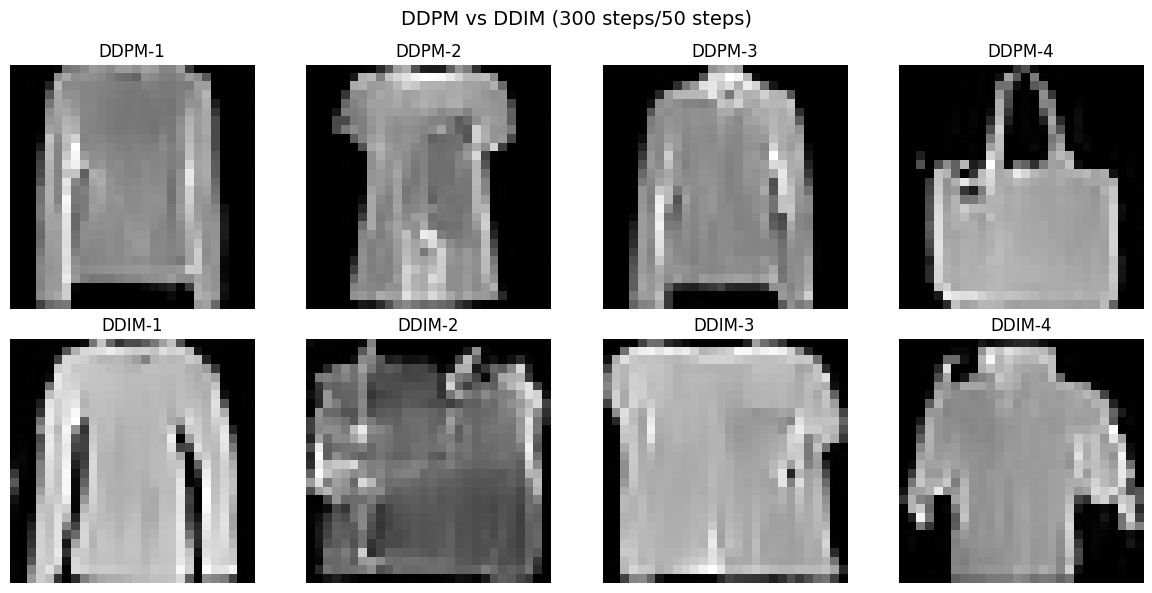

时间对比: DDPM 7.20s vs DDIM 1.21s


In [65]:
import time


print("生成对比图像中...")

# DDPM 300步
start = time.time()
samples_ddpm = sample(model, image_size=image_size, batch_size=8, channels=channels)
ddpm_time = time.time() - start
print(f"DDPM 完成: {ddpm_time:.2f}秒")

# DDIM 50步
start = time.time()
samples_ddim = sample_ddim(model, image_size=image_size, batch_size=8, channels=channels, num_steps=50)
ddim_time = time.time() - start
print(f"DDIM 完成: {ddim_time:.2f}秒")


fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # DDPM
    img_ddpm = samples_ddpm[-1][i].reshape(28, 28, 1).squeeze()
    axes[0, i].imshow(img_ddpm, cmap='gray')
    axes[0, i].set_title(f'DDPM-{i+1}')
    axes[0, i].axis('off')

    # DDIM
    img_ddim = samples_ddim[-1][i].reshape(28, 28, 1).squeeze()
    axes[1, i].imshow(img_ddim, cmap='gray')
    axes[1, i].set_title(f'DDIM-{i+1}')
    axes[1, i].axis('off')


axes[0, 0].set_ylabel('DDMP\n300 steps', fontsize=12)
axes[1, 0].set_ylabel('DDIM\n50 steps', fontsize=12)

plt.suptitle(f'DDPM vs DDIM (300 steps/50 steps)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"时间对比: DDPM {ddpm_time:.2f}s vs DDIM {ddim_time:.2f}s")

# **DPM-SOLVER**

In [66]:
import torch
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def dpm_solver_sample(model, shape, num_inference_steps=20, order=2, eta=0.0):
    """
    DPM-Solver++ 采样
    """
    device = next(model.parameters()).device
    b = shape[0]

    # 使用全局的timesteps总数
    global timesteps
    timestep_list = get_dpm_timesteps(num_inference_steps, timesteps)

    # 从纯噪声开始
    sample = torch.randn(shape, device=device)

    # 存储模型输出的历史
    model_outputs = []
    timestep_history = []

    for i, timestep in enumerate(tqdm(timestep_list, desc='DPM-Solver++')):
        timestep_tensor = torch.full((b,), timestep, device=device, dtype=torch.long)

        # 模型预测噪声
        model_output = model(sample, timestep_tensor)
        model_outputs.append(model_output)
        timestep_history.append(timestep)

        # 获取下一个时间步
        prev_timestep = timestep_list[i + 1] if i < len(timestep_list) - 1 else 0

        if i == 0 or order == 1 or len(model_outputs) < order:
            # 前几步或一阶方法使用一阶更新
            sample = dpm_solver_first_order_update(
                model_output, timestep, prev_timestep, sample, device
            )
        elif order == 2:
            # 二阶更新
            sample = dpm_solver_second_order_update(
                model_outputs[-2:], timestep_history[-2:], prev_timestep, sample, device
            )
        elif order == 3:
            # 三阶更新 (简化为二阶)
            sample = dpm_solver_second_order_update(
                model_outputs[-2:], timestep_history[-2:], prev_timestep, sample, device
            )

        # 保持历史长度
        if len(model_outputs) > order:
            model_outputs = model_outputs[-order:]
            timestep_history = timestep_history[-order:]

    return sample

def get_dpm_timesteps(num_inference_steps, total_timesteps):
    """
    生成DPM-Solver的时间步序列
    """
    step_ratio = total_timesteps // num_inference_steps
    timestep_list = (np.arange(0, num_inference_steps) * step_ratio).round()[::-1].astype(np.int64)
    timestep_list = np.concatenate([timestep_list, [0]])
    return timestep_list.tolist()

def dpm_solver_first_order_update(model_output, timestep, prev_timestep, sample, device):
    """
    DPM-Solver 一阶更新 (类似DDIM)
    """
    global alphas_cumprod
    b = sample.shape[0]

    # 🔧 修正：创建正确的tensor给extract函数
    if timestep == 0:
        alpha_t = torch.ones(sample.shape[:1] + (1,) * (len(sample.shape) - 1), device=device)
        sigma_t = torch.zeros(sample.shape[:1] + (1,) * (len(sample.shape) - 1), device=device)
    else:
        timestep_tensor = torch.full((b,), timestep, device=device, dtype=torch.long)
        alpha_t_cumprod = extract(alphas_cumprod, timestep_tensor, sample.shape)
        alpha_t = torch.sqrt(alpha_t_cumprod)
        sigma_t = torch.sqrt(1 - alpha_t_cumprod)

    # 获取下一时间步的系数
    if prev_timestep == 0:
        alpha_s = torch.ones_like(alpha_t)
        sigma_s = torch.zeros_like(sigma_t)
    else:
        prev_timestep_tensor = torch.full((b,), prev_timestep, device=device, dtype=torch.long)
        alpha_s_cumprod = extract(alphas_cumprod, prev_timestep_tensor, sample.shape)
        alpha_s = torch.sqrt(alpha_s_cumprod)
        sigma_s = torch.sqrt(1 - alpha_s_cumprod)

    # 预测原始图像 x_0
    pred_x0 = (sample - sigma_t * model_output) / alpha_t

    # DPM-Solver 一阶公式 (等价于DDIM)
    sample_prev = alpha_s * pred_x0 + sigma_s * model_output

    return sample_prev

def dpm_solver_second_order_update(model_outputs, timestep_history, prev_timestep, sample, device):
    """
    DPM-Solver 二阶更新 (简化版本)
    """
    # 使用线性组合近似二阶效果
    m1, m2 = model_outputs[0], model_outputs[1]

    # 简单的线性外插
    improved_output = 1.5 * m2 - 0.5 * m1

    # 使用改进的输出进行一阶更新
    return dpm_solver_first_order_update(improved_output, timestep_history[1], prev_timestep, sample, device)

@torch.no_grad()
def sample_dpm_solver(model, image_size, batch_size=16, channels=3, num_steps=20, order=2):
    """
    DPM-Solver++ 采样的便捷接口
    """
    result = dpm_solver_sample(
        model,
        shape=(batch_size, channels, image_size, image_size),
        num_inference_steps=num_steps,
        order=order
    )

    return [result.cpu().numpy()]

开始DPM-Solver++采样...


DPM-Solver++: 100%|██████████| 21/21 [00:00<00:00, 42.20it/s]


DPM-Solver++ (20步) 完成: 0.50秒


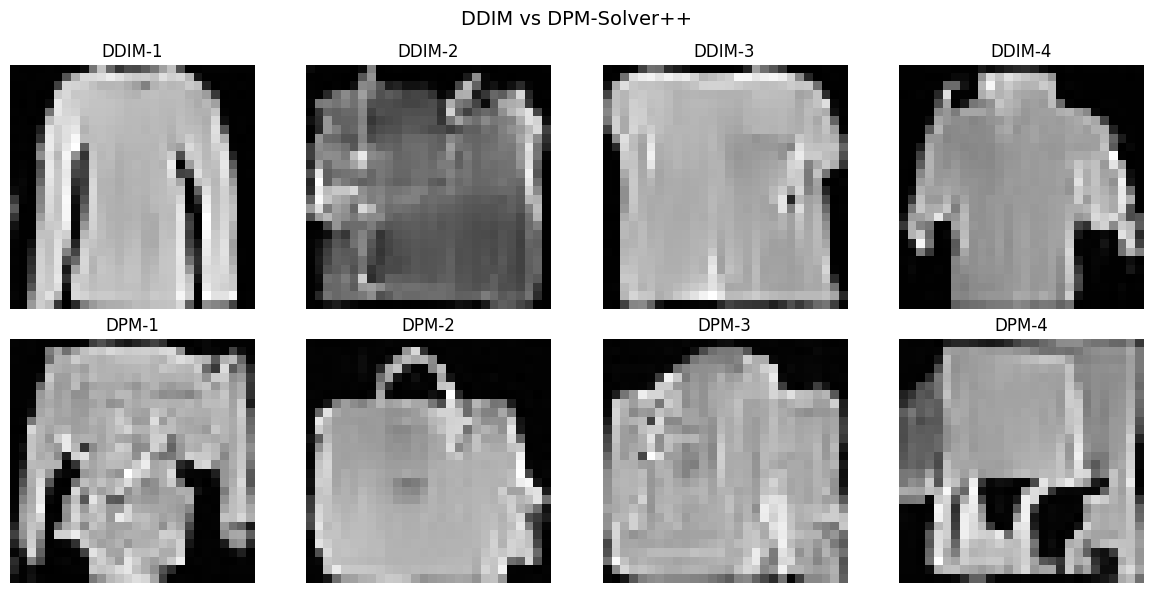

时间对比: DDIM 1.21s vs DPM-Solver++ 0.50s
DPM-Solver++ 加速比: 2.4x


In [67]:
# 替换你现有的采样代码
print("开始DPM-Solver++采样...")

# 20步高质量采样
start = time.time()
samples_dpm = sample_dpm_solver(
    model,
    image_size=image_size,
    batch_size=8,
    channels=channels,
    num_steps=20,  # 仅需20步！
    order=2        # 二阶方法，推荐
)
dpm_time = time.time() - start

print(f"DPM-Solver++ (20步) 完成: {dpm_time:.2f}秒")

# 显示结果
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # DDIM 50步
    img_ddim = samples_ddim[0][i].reshape(28, 28, 1).squeeze()
    axes[0, i].imshow(img_ddim, cmap='gray')
    axes[0, i].set_title(f'DDIM-{i+1}')
    axes[0, i].axis('off')

    # DPM-Solver++ 20步
    img_dpm = samples_dpm[0][i].reshape(28, 28, 1).squeeze()
    axes[1, i].imshow(img_dpm, cmap='gray')
    axes[1, i].set_title(f'DPM-{i+1}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('DDIM\n50 steps', fontsize=12)
axes[1, 0].set_ylabel('DPM-Solver++\n20 steps', fontsize=12)

plt.suptitle('DDIM vs DPM-Solver++', fontsize=14)
plt.tight_layout()
plt.show()

print(f"时间对比: DDIM {ddim_time:.2f}s vs DPM-Solver++ {dpm_time:.2f}s")
print(f"DPM-Solver++ 加速比: {ddim_time/dpm_time:.1f}x")